In [1]:
# Import Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image

In [2]:
# Load the Saved Model
model = tf.keras.models.load_model("best_model.keras")

In [3]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 7)                 903       
                                                                 
Total params: 2422855 (9.24 MB)
Trainable params: 164871

In [4]:
# Define Emotion Classes
class_names = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

In [5]:
# Give Image Path
image_path = r"C:\Users\avani\Documents\DeepFER\dataset\Archive-3\test\sad\PrivateTest_528072.jpg"


In [6]:
# Check Whether Image Exists
import os

print("Current Working Directory:")
print(os.getcwd())

print()

print("Image Exists:", os.path.exists(image_path))

Current Working Directory:
c:\Users\avani\Documents\DeepFER\notebooks

Image Exists: True


In [7]:
# Load the Image
img = image.load_img(
    image_path,
    target_size=(224,224)
)

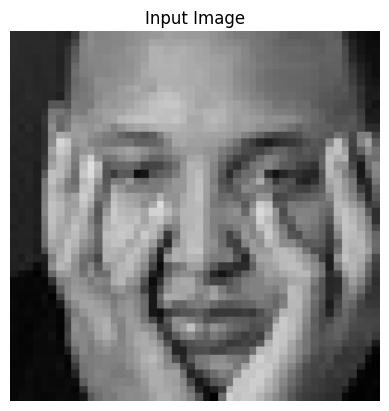

In [8]:
# Display Image
plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [9]:
# Convert Image to Array
img_array = image.img_to_array(img)

In [10]:
# Normalize Image
img_array = img_array / 255.0

In [11]:
# Add Batch Dimension
img_array = np.expand_dims(img_array, axis=0)
print(img_array.shape)

(1, 224, 224, 3)


In [14]:
prediction = model.predict(img_array)

1/1 [==============================] - 2s 2s/step


In [15]:
# Predict Emotion
predicted_index = np.argmax(prediction)

predicted_emotion = class_names[predicted_index]

confidence = np.max(prediction)

print("Predicted Emotion:", predicted_emotion)

print(f"Confidence: {confidence*100:.2f}%")

Predicted Emotion: sad
Confidence: 57.24%


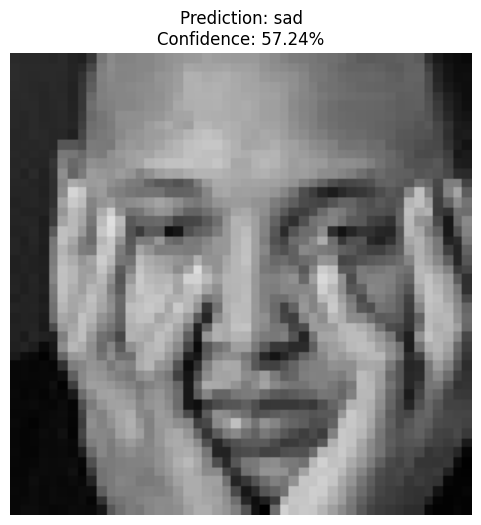

In [16]:
# Show Final Result
plt.figure(figsize=(6,6))

plt.imshow(img)

plt.axis("off")

plt.title(
    f"Prediction: {predicted_emotion}\nConfidence: {confidence*100:.2f}%"
)

plt.show()